In [3]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("==========================================")
print(" PHASE 1: DATA MINING & CLINICAL CLEANING")
print("==========================================")

# 1. Load the raw uploaded data
df = pd.read_csv('GDSC2-dataset.csv')
raw_rows, raw_cols = df.shape
print(f"--> [RAW DATA] Uploaded Data Dimensions: {raw_rows} rows, {raw_cols} columns")

# 2. Handle Missing Values
print("\n--> Initiating Data Cleaning...")
# Drop rows missing core pharmacokinetic metrics
df = df.dropna(subset=['LN_IC50', 'AUC', 'RMSE'])
# Impute missing biological pathways
df['PATHWAY_NAME'] = df['PATHWAY_NAME'].fillna('Unknown_Pathway')
print("    - Missing values handled (Dropped empty targets, imputed pathways).")

# 3. Handle Outliers (IQR Method)
def remove_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return dataframe[(dataframe[column] >= lower_bound) & (dataframe[column] <= upper_bound)]

df = remove_outliers_iqr(df, 'AUC')
df = remove_outliers_iqr(df, 'RMSE')
df = remove_outliers_iqr(df, 'LN_IC50')
print("    - Extreme clinical outliers removed using Interquartile Range (IQR).")

# 4. Filter Pathways for Robustness
top_pathways = df['PATHWAY_NAME'].value_counts().nlargest(5).index
df = df[df['PATHWAY_NAME'].isin(top_pathways)]
print("    - Filtered data to top 5 biological pathways for statistical robustness.")

# 5. Display Cleaned Data Shape
cleaned_rows, cleaned_cols = df.shape
print(f"\n--> [CLEANED DATA] Final Working Dimensions: {cleaned_rows} rows, {cleaned_cols} columns")
print(f"--> Total rows removed during cleaning: {raw_rows - cleaned_rows}")


 PHASE 1: DATA MINING & CLINICAL CLEANING
--> [RAW DATA] Uploaded Data Dimensions: 61895 rows, 19 columns

--> Initiating Data Cleaning...
    - Missing values handled (Dropped empty targets, imputed pathways).
    - Extreme clinical outliers removed using Interquartile Range (IQR).
    - Filtered data to top 5 biological pathways for statistical robustness.

--> [CLEANED DATA] Final Working Dimensions: 23779 rows, 19 columns
--> Total rows removed during cleaning: 38116


In [4]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import LabelEncoder

print("==========================================")
print(" PHASE 2: FEATURE ENGINEERING")
print("==========================================")

# 1. Create New Feature: Efficacy Index
df['efficacy_index'] = df['AUC'] / (df['RMSE'] + 0.0001)

# 2. Define Target: Binary Classification
threshold = df['LN_IC50'].median()
df['is_sensitive'] = (df['LN_IC50'] < threshold).astype(int)

# 3. Categorical Encoding
le_pathway = LabelEncoder()
le_drug = LabelEncoder()
df['pathway_encoded'] = le_pathway.fit_transform(df['PATHWAY_NAME'])
df['drug_encoded'] = le_drug.fit_transform(df['DRUG_NAME'])

# 4. Select Baseline Features
features = ['MIN_CONC', 'MAX_CONC', 'AUC', 'RMSE', 'Z_SCORE', 'efficacy_index', 'pathway_encoded', 'drug_encoded']
X = df[features]
y = df['is_sensitive']

# 5. Filter Method Feature Selection
selector = SelectKBest(score_func=f_classif, k=6)
X_selected = selector.fit_transform(X, y)
selected_cols = X.columns[selector.get_support()].tolist()

print(f"--> Top Predictive Features Selected via Filter Method: {selected_cols}")

 PHASE 2: FEATURE ENGINEERING
--> Top Predictive Features Selected via Filter Method: ['MIN_CONC', 'MAX_CONC', 'AUC', 'RMSE', 'Z_SCORE', 'efficacy_index']


 PHASE 3: HIGH-RESOLUTION EDA
Generating Clinical Visualizations...


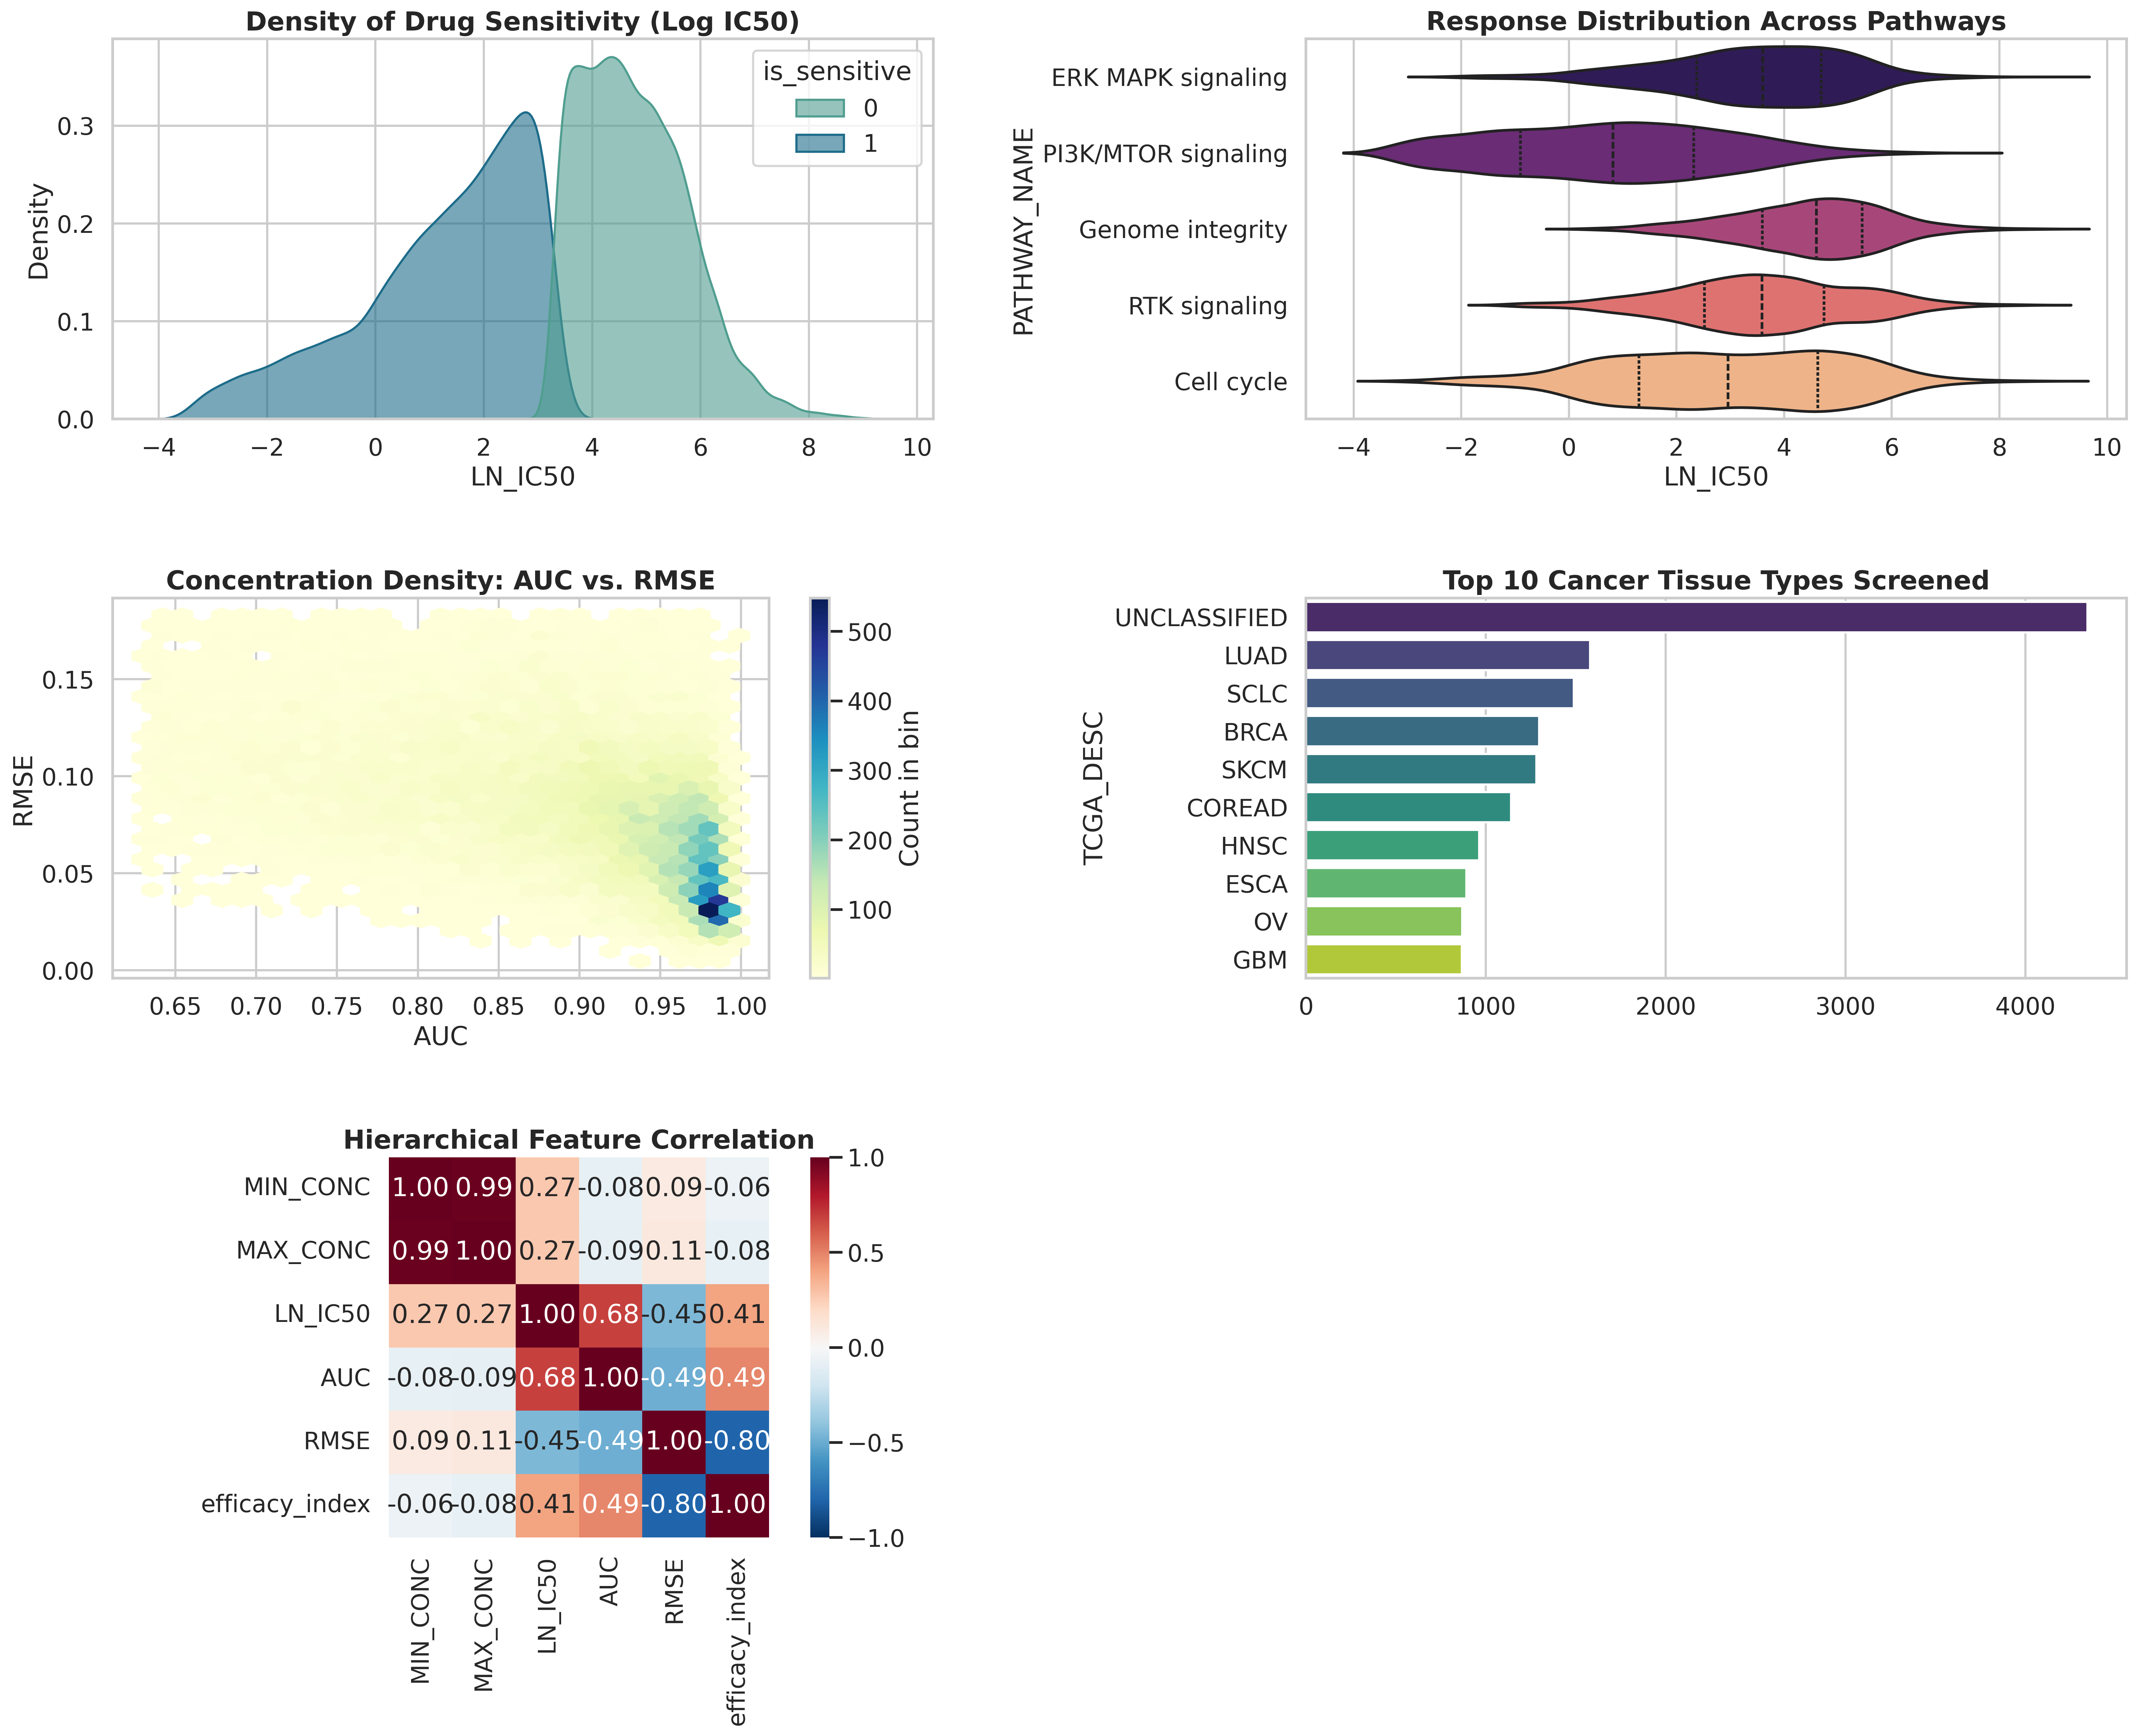

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

print("==========================================")
print(" PHASE 3: HIGH-RESOLUTION EDA")
print("==========================================")
print("Generating Clinical Visualizations...")

sns.set_theme(style="whitegrid", context="talk", palette="Set2")
plt.rcParams['figure.dpi'] = 300

fig = plt.figure(figsize=(22, 18))

# Plot 1: Density Plot
plt.subplot(3, 2, 1)
sns.kdeplot(data=df, x='LN_IC50', hue='is_sensitive', fill=True, common_norm=False, palette='crest', alpha=0.6)
plt.title('Density of Drug Sensitivity (Log IC50)', fontweight='bold')

# Plot 2: Violin Plot
plt.subplot(3, 2, 2)
sns.violinplot(x='LN_IC50', y='PATHWAY_NAME', data=df, palette='magma', inner='quartile')
plt.title('Response Distribution Across Pathways', fontweight='bold')

# Plot 3: Hexbin Density Plot
plt.subplot(3, 2, 3)
plt.hexbin(df['AUC'], df['RMSE'], gridsize=30, cmap='YlGnBu', mincnt=1)
plt.colorbar(label='Count in bin')
plt.title('Concentration Density: AUC vs. RMSE', fontweight='bold')
plt.xlabel('AUC'); plt.ylabel('RMSE')

# Plot 4: Bar Plot
plt.subplot(3, 2, 4)
top_cells = df['TCGA_DESC'].value_counts().nlargest(10)
sns.barplot(x=top_cells.values, y=top_cells.index, palette='viridis')
plt.title('Top 10 Cancer Tissue Types Screened', fontweight='bold')

# Plot 5: Feature Correlation Heatmap
plt.subplot(3, 2, 5)
corr_matrix = df[['MIN_CONC', 'MAX_CONC', 'LN_IC50', 'AUC', 'RMSE', 'efficacy_index']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt='.2f', vmin=-1, vmax=1, square=True)
plt.title('Hierarchical Feature Correlation', fontweight='bold')

plt.tight_layout(pad=3.0)
plt.show()

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, precision_score, recall_score

print("==========================================")
print(" PHASE 4: MODELING & FINE-TUNING")
print("==========================================")

# 1. Train/Test Split & Scaling
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Baseline Model Comparison (3 Algorithms)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

print("--- Baseline Algorithm Performance ---")
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    print(f"{name} -> Precision: {precision_score(y_test, y_pred, average='weighted'):.2f} | Recall: {recall_score(y_test, y_pred, average='weighted'):.2f}")

# 3. Hyperparameter Tuning (Random Forest)
print("\n--> Fine-Tuning Optimal Model (Random Forest) via GridSearchCV...")
param_grid = {'n_estimators': [50, 100], 'max_depth': [10, 20], 'min_samples_split': [2, 5]}
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring='f1_weighted', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)
best_model = grid_search.best_estimator_

# 4. Final Evaluation
final_preds = best_model.predict(X_test_scaled)
print("\n--- Final Tuned Model Metrics ---")
print(classification_report(y_test, final_preds, target_names=['Resistant', 'Sensitive']))


 PHASE 4: MODELING & FINE-TUNING
--- Baseline Algorithm Performance ---
Logistic Regression -> Precision: 0.91 | Recall: 0.91
Random Forest -> Precision: 0.95 | Recall: 0.95
Gradient Boosting -> Precision: 0.95 | Recall: 0.95

--> Fine-Tuning Optimal Model (Random Forest) via GridSearchCV...

--- Final Tuned Model Metrics ---
              precision    recall  f1-score   support

   Resistant       0.95      0.95      0.95      2374
   Sensitive       0.95      0.95      0.95      2382

    accuracy                           0.95      4756
   macro avg       0.95      0.95      0.95      4756
weighted avg       0.95      0.95      0.95      4756



 PHASE 5: EVALUATION PLOTS & EXPORT
✅ gdsc_selector.pkl is ready to download!


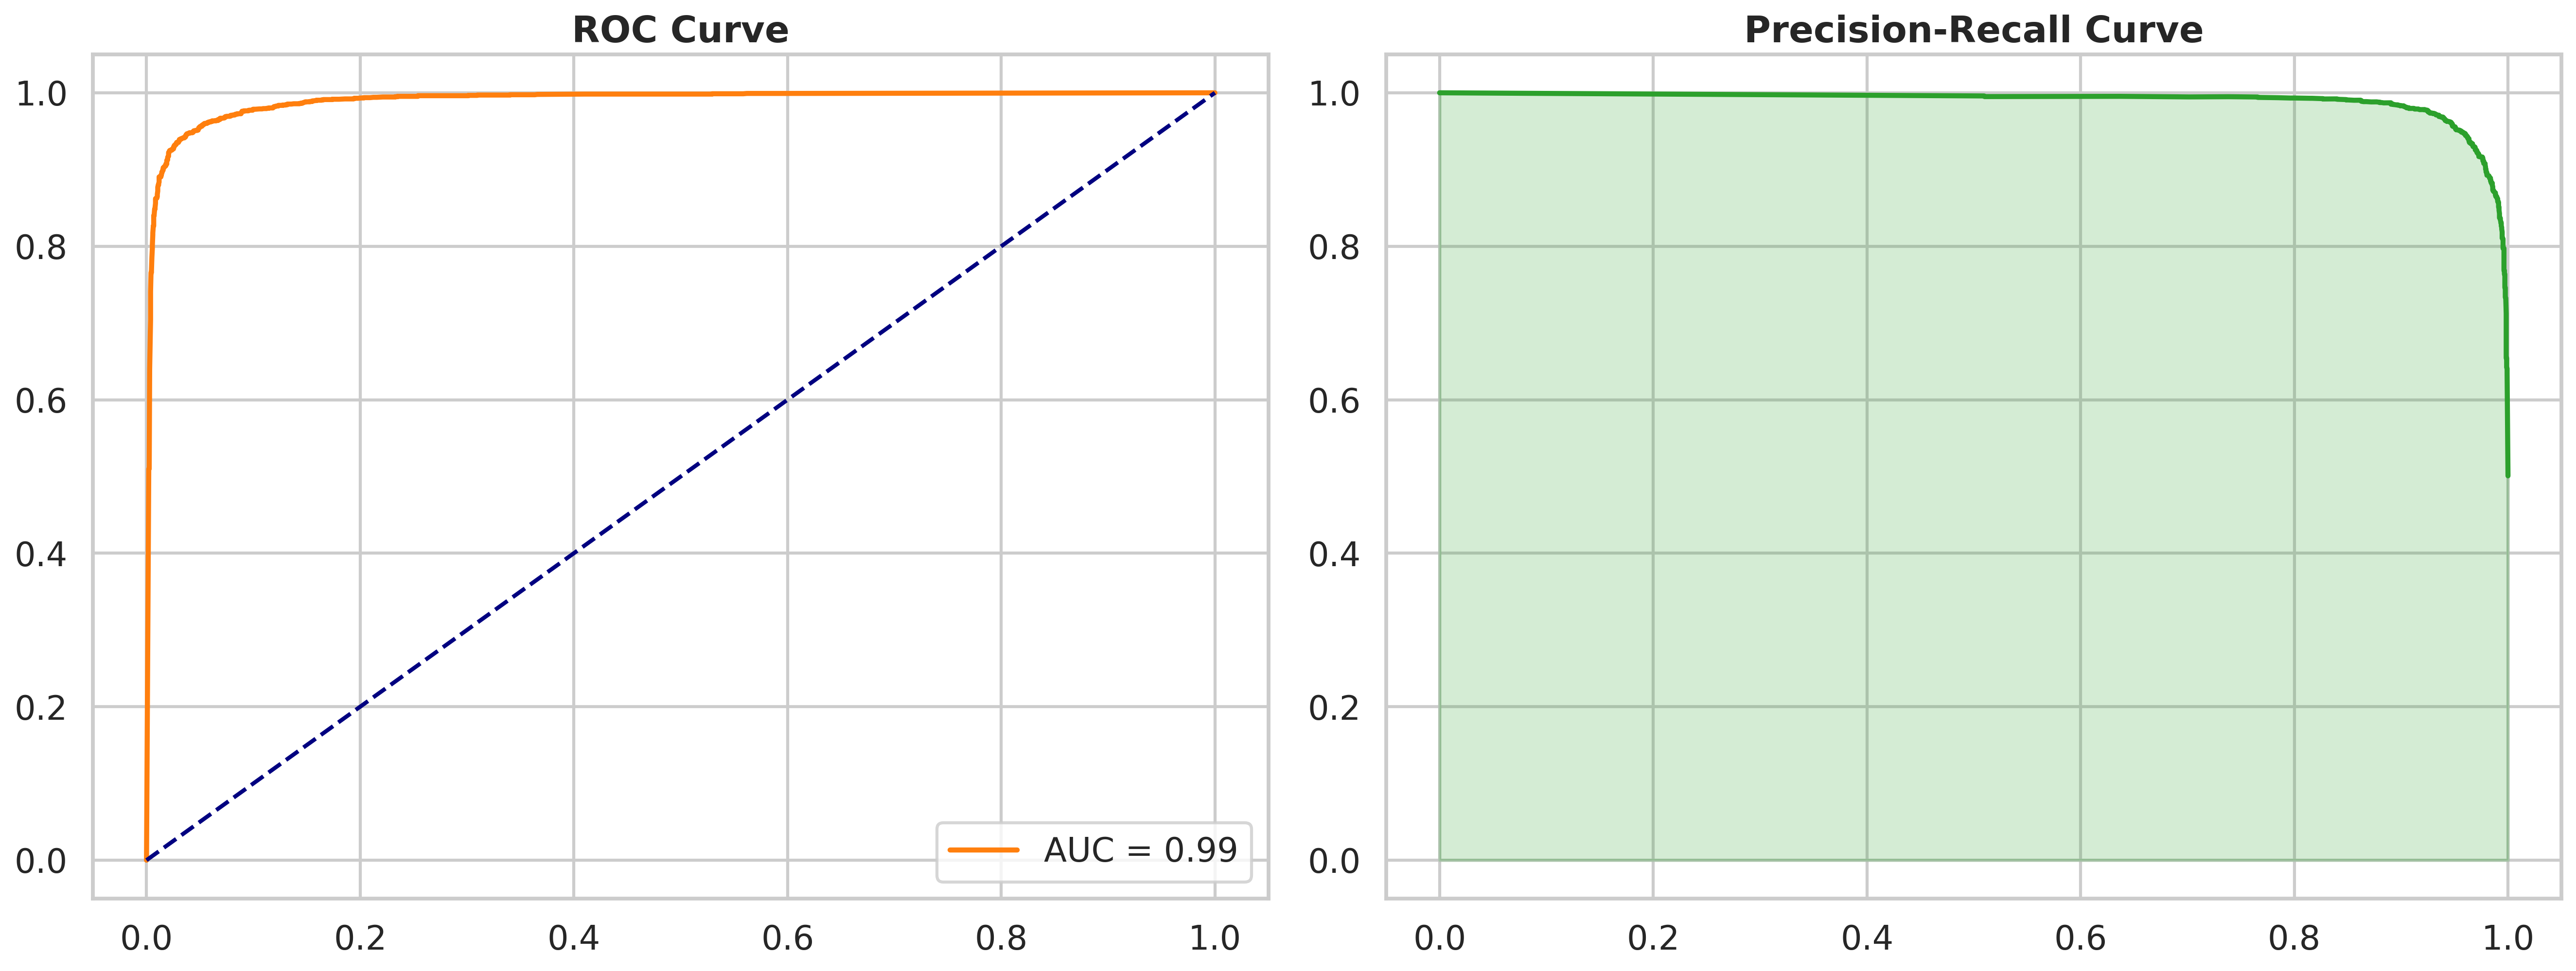


--> Exporting Models for Deployment...
✅ SUCCESS: 'gdsc_model.pkl', 'gdsc_scaler.pkl', and 'pathway_encoder.pkl' are ready for download!


In [7]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import joblib

print("==========================================")
print(" PHASE 5: EVALUATION PLOTS & EXPORT")
print("==========================================")

# 1. Validation Curves
y_probs = best_model.predict_proba(X_test_scaled)[:, 1]
fig2, axes = plt.subplots(1, 2, figsize=(18, 7))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
axes[0].plot(fpr, tpr, color='#ff7f0e', lw=2.5, label=f'AUC = {auc(fpr, tpr):.2f}')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_title('ROC Curve', fontweight='bold'); axes[0].legend(loc="lower right")

# Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_test, y_probs)
axes[1].plot(rec, prec, color='#2ca02c', lw=2.5)
axes[1].fill_between(rec, prec, alpha=0.2, color='#2ca02c')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
import joblib
joblib.dump(selector, 'gdsc_selector.pkl')
print("✅ gdsc_selector.pkl is ready to download!")
plt.tight_layout()
plt.show()

# 2. Deployment Export
print("\n--> Exporting Models for Deployment...")
joblib.dump(best_model, 'gdsc_model.pkl')
joblib.dump(scaler, 'gdsc_scaler.pkl')
joblib.dump(le_pathway, 'pathway_encoder.pkl')
print("✅ SUCCESS: 'gdsc_model.pkl', 'gdsc_scaler.pkl', and 'pathway_encoder.pkl' are ready for download!")
